In [1]:
import glob
import os
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr


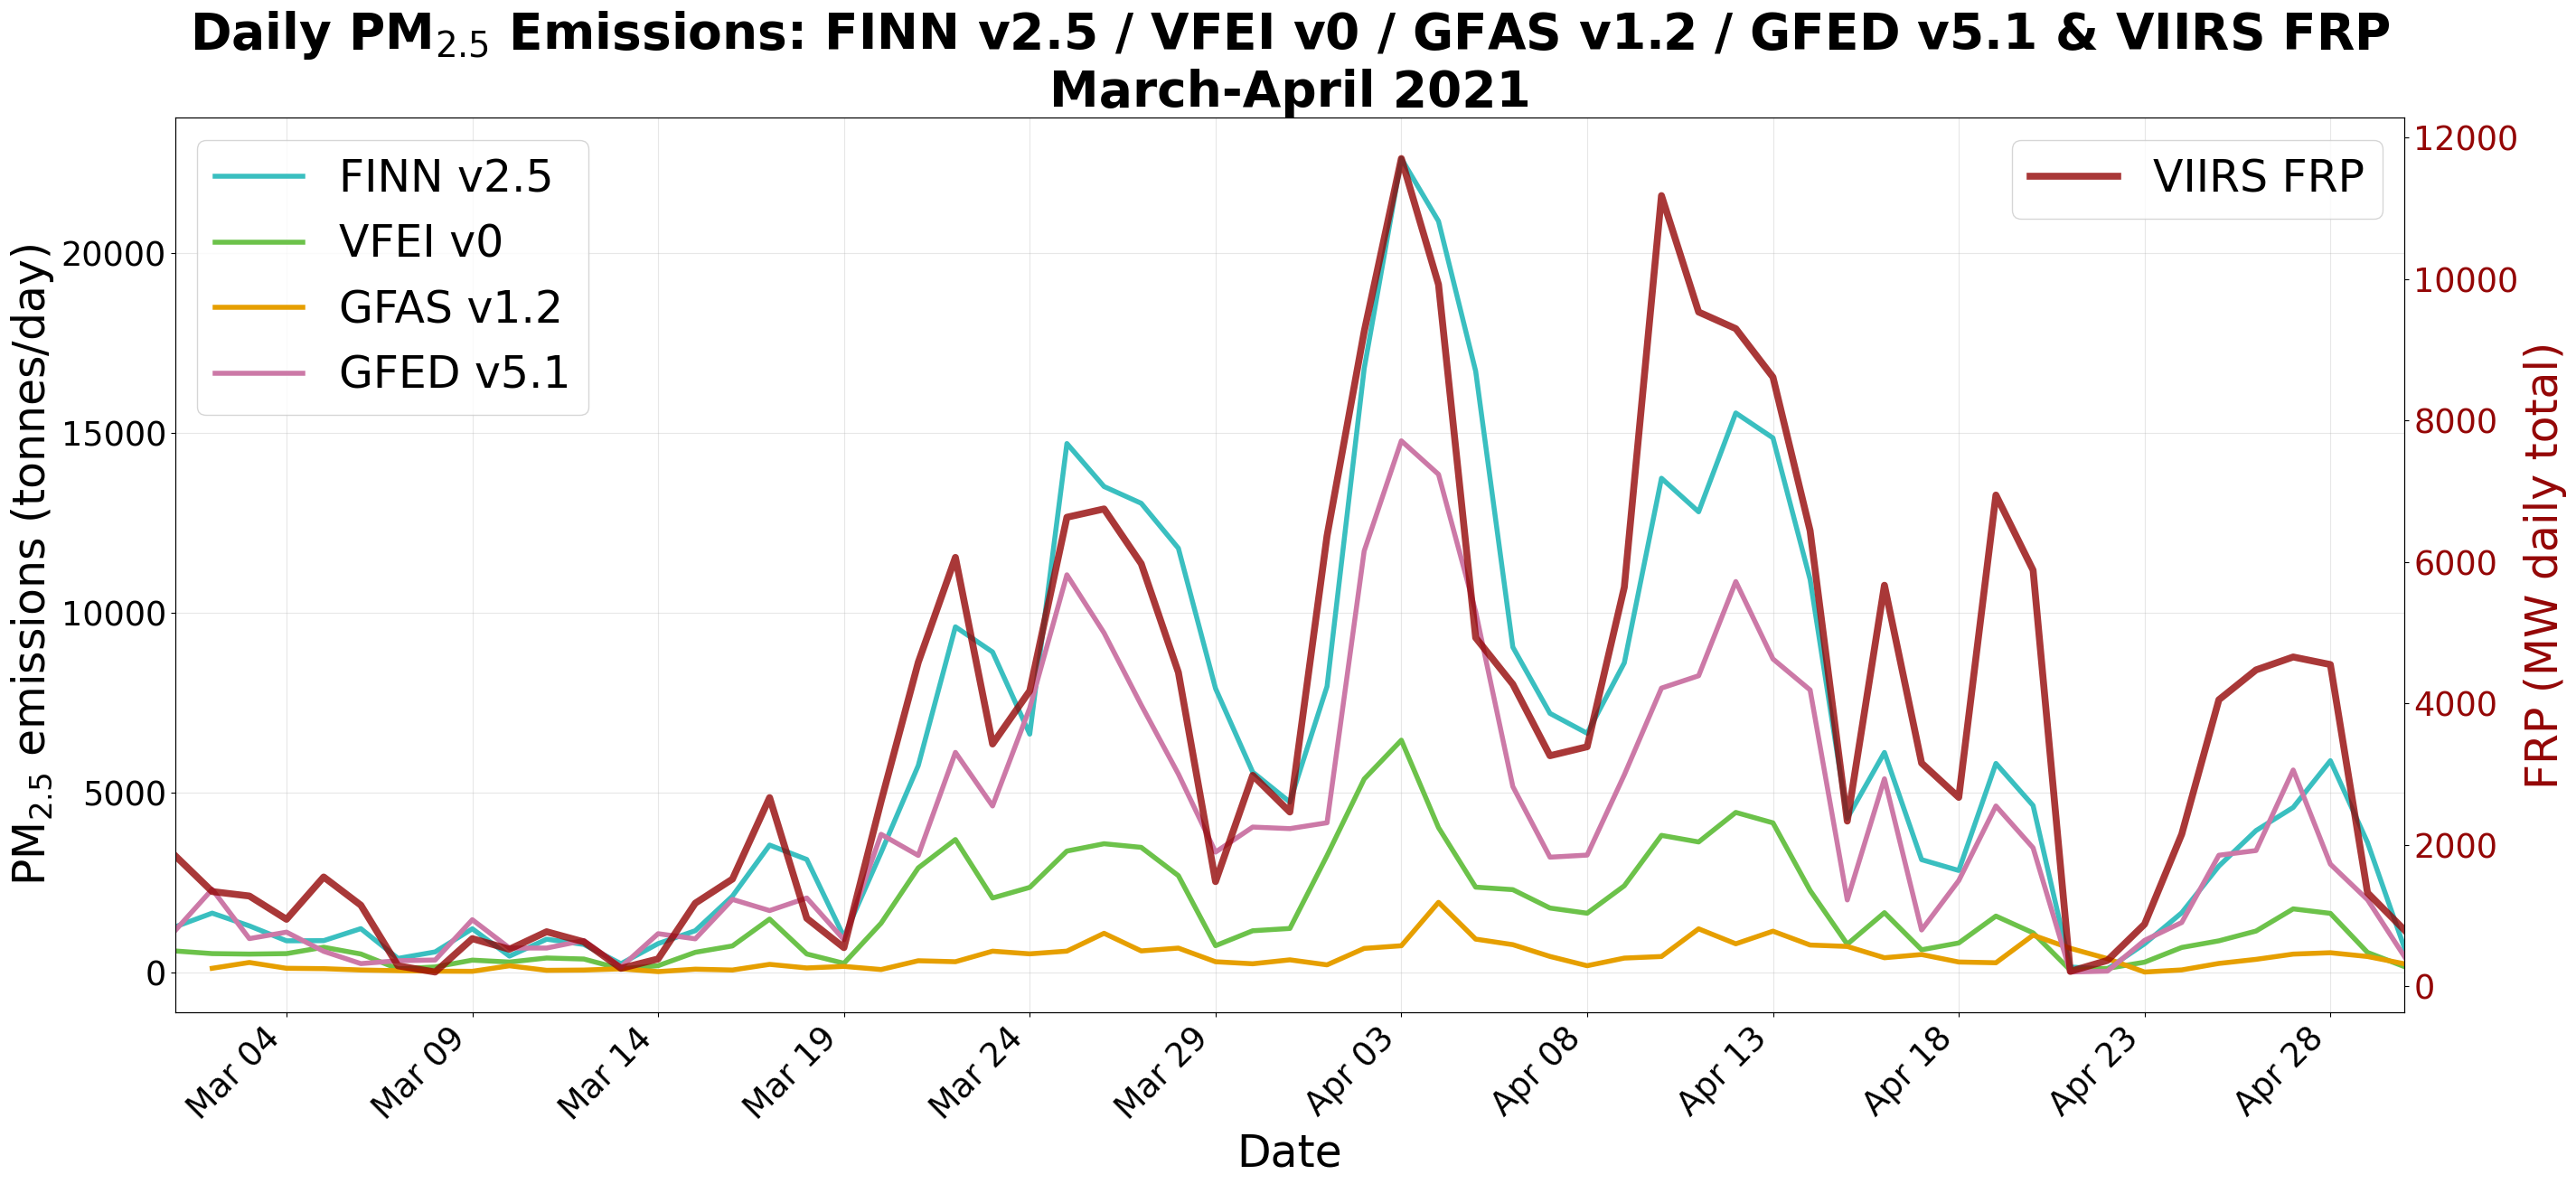

In [2]:
LAT_MIN, LAT_MAX = 26.4, 30.4
LON_MIN, LON_MAX = 80.1, 88.2
START, END = "2021-03-01", "2021-04-30"

# VFEI v0
vfei_files = sorted(glob.glob(os.path.join("VFEI v0 2021", "vfei_v0_0.005deg_*.nc")))

vfei_records = []
for f in vfei_files:
    datestr = os.path.basename(f).split("_")[-1].replace(".nc", "")
    date = pd.to_datetime(datestr, format="%Y%m%d")

    ds = xr.open_dataset(f)
    lat, lon = ds.lat.values, ds.lon.values
    mask = (lat >= LAT_MIN) & (lat <= LAT_MAX) & (lon >= LON_MIN) & (lon <= LON_MAX)

    #PM2_5 units = kg s-1 m-2 (flux),
    # grid_area units = 'm2', so PM2_5 * grid_area * 86400 (seconds in a day) = kg/day 
    daily_kg = float(np.sum(ds.PM2_5.values[mask] * ds.grid_area.values[mask] * 86400))

    vfei_records.append({"date": date, "vfei_kg_day": daily_kg})
    ds.close()

vfei = pd.DataFrame(vfei_records).sort_values("date")
vfei.to_csv("vfei_daily.csv", index=False)

# FINN v2.5
finn_ds = xr.open_dataset(
    "emissions-finnv2.5modvrs_PM25_bb_surface_daily_20210101-20211231_0.1x0.1.nc")

finn_sub = finn_ds.sel(
    time=slice(START, END), lat=slice(LAT_MIN, LAT_MAX), lon=slice(LON_MIN, LON_MAX))

R = 6371000.0  # m, Earth radius
dlat = dlon = 0.1 * np.pi / 180
cell_area = R**2 * dlon * dlat * np.cos(np.deg2rad(finn_sub.lat.values))  
area2d = np.repeat(cell_area[:, None], finn_sub.sizes["lon"], axis=1)

flux = finn_sub["fire_modisviirs_PM25"].values #molecules cm-2 s-1
NA = 6.022e23
MW = 12.0  # g/mol 
mass_flux = flux / NA * MW * 1e-3 * 1e4  # kg m-2 s-1 (flux units)

finn_daily_kg = np.nansum(mass_flux * area2d[None, :, :] * 86400, axis=(1, 2)) # kg/day units
finn = pd.DataFrame(
    {"date": pd.to_datetime(finn_sub.time.values), "finn_kg_day": finn_daily_kg}
)
finn.to_csv("finn_daily.csv", index=False)

# GFAS
gfas_ds = xr.open_dataset("GFAS_Wildfire_Flux_of_PM2p5.nc")

gfas_sub = gfas_ds.sel(
    valid_time=slice(START, END),
    latitude=slice(LAT_MAX, LAT_MIN), 
    longitude=slice(LON_MIN, LON_MAX),
)

dlat = dlon = 0.1 * np.pi / 180
cell_area = R**2 * dlon * dlat * np.cos(np.deg2rad(gfas_sub.latitude.values))
area2d = np.repeat(cell_area[:, None], gfas_sub.sizes["longitude"], axis=1)

# pm2p5fire units = kg m-2 s-1 (flux) -> kg/day
gfas_daily_kg = np.nansum(
    gfas_sub["pm2p5fire"].values * area2d[None, :, :] * 86400, axis=(1, 2)
)
gfas = pd.DataFrame(
    {"date": pd.to_datetime(gfas_sub.valid_time.values), "gfas_kg_day": gfas_daily_kg}
)
gfas.to_csv("gfas_daily.csv", index=False)

# VIIRS FRP
viirs_raw = pd.read_excel("fire_archive_SV-C2_760260.xlsx")
viirs_raw["date"] = pd.to_datetime(viirs_raw["acq_date"])
 
# spatial filter 
viirs_raw = viirs_raw[
    viirs_raw["latitude"].between(LAT_MIN, LAT_MAX)
    & viirs_raw["longitude"].between(LON_MIN, LON_MAX)
    & viirs_raw["date"].between(START, END)
    & viirs_raw["confidence"].isin(["n", "h"]) 
]
 
viirs = (
    viirs_raw.groupby("date")["frp"]
    .sum()
    .reset_index()
    .rename(columns={"frp": "viirs_frp_mw"})
)
viirs.to_csv("viirs_daily.csv", index=False)

#GFED
gfed_records = []
for f in ["GFED5.1_daily_2021-04.nc", "GFED5.1_daily_2021-03.nc"]:
    ds = xr.open_dataset(f)
    pm25 = ds["PM2.5"].sel(lat=slice(LAT_MIN, LAT_MAX), lon=slice(LON_MIN, LON_MAX))
    daily_kg = pm25.sum(dim=("lat", "lon")).values / 1000  # g -> kg (already per-cell mass, no area weighting)
    dates = pd.to_datetime(ds.time.values).normalize()
    gfed_records.append(pd.DataFrame({"date": dates, "gfed_kg_day": daily_kg}))
    ds.close()

gfed = pd.concat(gfed_records).sort_values("date").reset_index(drop=True)
gfed = gfed[(gfed["date"] >= START) & (gfed["date"] <= END)]
gfed.to_csv("gfed_daily.csv", index=False)

# Poster scale plotting 
SCALE = 2.2  

fig, ax1 = plt.subplots(figsize=(13 * SCALE, 6 * SCALE))

ax1.plot(finn["date"], finn["finn_kg_day"] / 1000, color="#3ABFC0", lw=1.8 * SCALE,
           ms=3 * SCALE, label="FINN v2.5")
ax1.plot(vfei["date"], vfei["vfei_kg_day"] / 1000, color="#6CC24A", lw=1.8 * SCALE,
           ms=3 * SCALE, label="VFEI v0")
ax1.plot(gfas["date"], gfas["gfas_kg_day"] / 1000, color="#E69F00", lw=1.8 * SCALE,
          ms=3 * SCALE, label="GFAS v1.2")
ax1.plot(gfed["date"], gfed["gfed_kg_day"] / 1000, color="#CC79A7", lw=1.8 * SCALE,
         ms=3 * SCALE, label="GFED v5.1")

ax1.set_xlabel("Date", fontsize=16 * SCALE)
ax1.set_ylabel("PM$_{2.5}$ emissions (tonnes/day)", fontsize=16 * SCALE)
ax1.set_xlim(pd.Timestamp(START), pd.Timestamp(END))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax1.tick_params(axis="both", labelsize=12 * SCALE)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left", fontsize=16 * SCALE)

ax2 = ax1.twinx()
ax2.plot(viirs["date"], viirs["viirs_frp_mw"], color="#940606", lw=2.5 * SCALE,
          alpha=0.8, label="VIIRS FRP")
ax2.set_ylabel("FRP (MW daily total)", color="#940606", fontsize=16 * SCALE)
ax2.tick_params(axis="y", labelcolor="#940606", labelsize=12 * SCALE)
ax2.legend(loc="upper right", fontsize=16 * SCALE)

ax1.set_title(
    "Daily PM$_{2.5}$ Emissions: FINN v2.5 / VFEI v0 / GFAS v1.2 / GFED v5.1 & VIIRS FRP\n"
    "March-April 2021",
    fontsize=18 * SCALE,
    fontweight="bold",
)

plt.tight_layout()